# Relacion 1b Nanoelectrónica

### Ejercicio 4

**Calcular y representar nuevamente los cinco primeros niveles de
energía ($𝐸_i$) permitidos y las funciones de onda asociadas para el pozo de
potencial de profundidad 2.5eV y anchura L=4nm. En este caso la solución
debe obtenerse discretizando el Hamiltoniano usando un método de
diferencias finitas, tal y como se explicará en clase (No hacer hasta que
se explique en clase).**


Para resolverlo impondré condiciones de contorno tipo Dirichlet. Asumiré que la penetración de la onda es muy pequeña, por lo que a una distancia de L/2 del pozo la onda será prácticamente nula, por lo que la haré 0.

Condiciones dirichlet:
$$
\Psi(x_{min}) = \Psi(x_{max}) = 0
$$

In [101]:
## LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt

In [102]:
### CODIGO PARA EJECUTAR VARIABLES #######################



##### VARIABLES #####

L = 4 #nm           #ANCHURA
V0 = 2.5 #ev          #Profundidad del pozo

N = 1000            #Cantidad de puntos de divisiones
x_min = -2*L
x_max = 2*L           #Dimensiones donde integraremos

numestados = 5      #Numero de estados que queremos calcular  


##### CONSTANTES ####

hbar = 197.33   ## eV nm

m = 511000      #eV (masa electrón)



#Creo el linspace de puntos y el espaciado
x = np.linspace(x_min, x_max, N)
dx = x[1] - x[0]

In [103]:
### DEFINIR EL POZO ################

V = np.zeros(N)

for i in range(N):
    if abs(x[i]) < L/2:
        V[i] = 0.0
    
    else:
        V[i] = V0

In [104]:
### DEFINIR EL HAMILTONIANO ####################

from scipy.sparse.linalg import eigsh #Librería recomendada en clase
from scipy.sparse import diags

coefi = hbar**2 / (2*m*dx**2)

#Defino la matriz con la diagonal y el offset

#Condiciones de Dirichlet: 
Vinterior=V[1:-1] #Impongo que el los puntos finales la onda sea 0

#Esto tendrá dimension N-2, por tanto trabajo con un n que sea N-2

N2 = N-2

diagonal = 2*coefi + Vinterior      #Diagonal del hamiltoniano
offset = -coefi * np.ones(N2 - 1)   #El offset tiene dimension (N-2) - 1

H = diags( [offset, diagonal, offset], offsets=[-1,0,1], format = 'csr') #Pongo la diagonal y el ofset en la "fila" +1 y -1 respectivamente
#El formato 'csr' es para almacenar matrices con muchos 0, así que tardará mucho menos


In [105]:
### EJECUTAR CÓDIGO ######################################


#Sacamos las energías y autofunciones del hamiltoniano--------------------------------------------------------

E, eigenpsi = eigsh(H, k=numestados, which='SA')

#Ordenamos según niveles porque la función según la librería PUEDE que no estén ordenados y yo quiero que E0 < E1 < E2 ...


indice = np.argsort(E)      #Creamos el orden
E=E[indice]                 #Lo ordenamos
eigenpsi=eigenpsi[:,indice] #También ordenamos las autofunciones

print(E)



# Normalizamos los estados ------------------------------------------------------------------------------------

for n in range(numestados):
    norma = np.sqrt(np.sum(dx*eigenpsi[:,n]**2))
    eigenpsi[:,n] = eigenpsi[:,n]/norma


# Le pongo los extremos que le había quitado antes: los 0 de Dirichlet -----------------------------------------

psi = np.zeros((N, numestados))     #Doble paréntesis porque es una matriz
psi[1:-1, :] = eigenpsi             #Creo una matriz de 0 donde cada fila estará el estado anterior, y le digo que me lo ponga "centrado", osea con el 0 al principio y al final


[0.02080133 0.08316192 0.18694711 0.3319166  0.51769538]


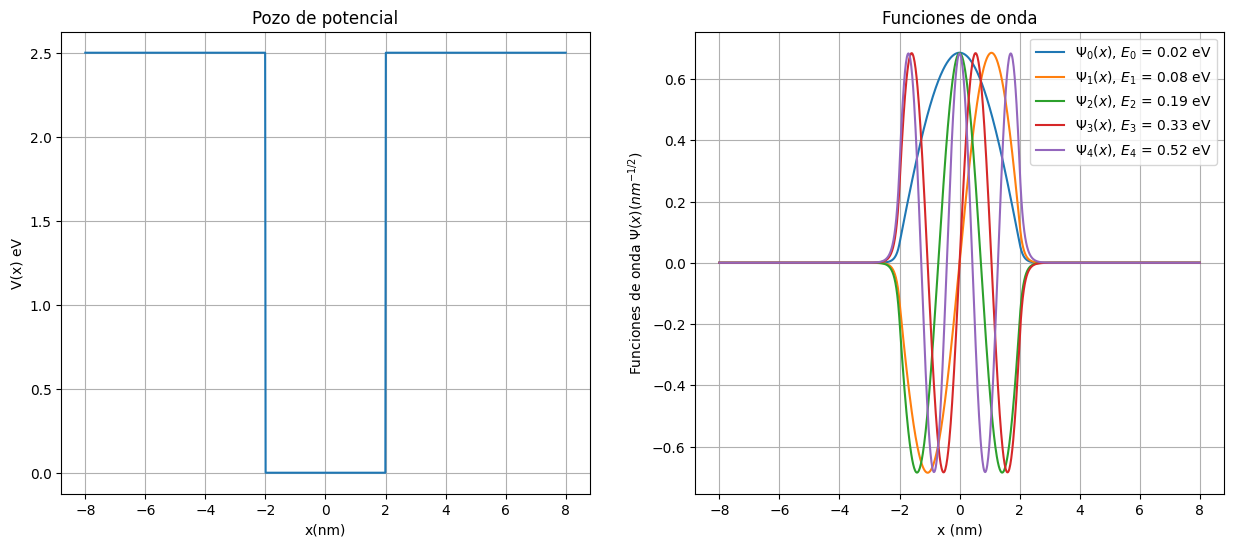

In [106]:
### PLOTEAR RESULTADOS ####################################33


fig, axes = plt.subplots(1,2,figsize=(15,6))

axes[0].plot(x,V)
axes[0].set_xlabel("x(nm)")
axes[0].set_ylabel("V(x) eV")
axes[0].set_title("Pozo de potencial")
axes[0].grid()


for n in range(numestados):
    axes[1].plot(x, psi[:,n], label=fr'$\Psi_{n}(x)$, $E_{n}$ = {E[n]:.2f} eV')

axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel(r"Funciones de onda $\Psi (x) (nm^{-1/2})$")
axes[1].set_title("Funciones de onda")
axes[1].legend()
axes[1].grid()
plt.show()


### Ejercicio 5

**En 1956 los científicos John Bardeen, Walter Brattain, and William
Shockley recibieron el Nobel de física por la invención del transistor de
estado sólido. Repase la lista de premios Nobel de física desde entonces
y mencione aquellos que estén relacionados de alguna manera con los
semiconductores y la electrónica.** 

Los ordenaré por fecha y comentaré brevemente lo que hicieron

- 1964: Nikolai Gennádiyevich, Aleksandr Mijáilovich y Charles Hard: Electrónica cuántica, osciladores y amplificadores basados en máser-láser.

- 1970: Louis Eugène Félix: Ferromagnetismo y antiferromagnetismo

- 1972: John Bardeen, Leon Neil Cooper, John Robert Schrieffer: Teoría de superconductividad y BCS.

- 1973: Leo Esaki, Ivar Giaever: Efecto túnel en semiconductores y superconductores.

- 1973: Brian Josepson: Efecto Josephson (corriente eléctrica por efecto tunel entre superconductores).

- 1977: Philip Warren, John hasbrouck, Nevill Francis: Investigaciones de estructura electrónica de sistemas magnéticos desordenados.

- 1978: Potr Leonídovich: Física de bajas temperaturas.

- 1987: Johannes Georg, Karl Alexander Müller: Superconductividad en materiales cerámicos.

- 1998: Robert B. Laughlin, Horst Ludwin Störmer, Daniel Chee Tsui: Fluido cuántico con excitaciones cargadas fraccionalmente.

- 2000: Zhorés Ivánovich, Herbert Kroemer: Heteroestructuras de semiconductores para optoelectrónica.

- 2000: Jack Kilby: Circuito integrado.

- 2003: Alekséi Alekséyevich, Vitaly Lázarevich, Anthony James: Teoría de superconductores y superfluidos.

- 2009: Charles K. Kao: Fibras ópticas.

- 2009: Willard S. Boyle, George E. Smith: Circuito semiconductor, sensor de carga acoplada.

- 2010: Andre Geim, Konstantin Novosiólov: Experimentos con grafeno de dos dimensiones.

- 2014: Isamu Akasaki, Hiroshi Amano, Shuji Nakamura: Diodos de emisión azules eficientes.


En total, 16 premios Nobel

### Ejercicio 6

**Haz un resumen de los siguientes videos**

##### ¿Cómo funciona un transistor? EL MOSFET:

Vídeo hecho en la UGR por el departamento de electrónica. Habla de la importancia de los transistores, dónde se encuentran y un uso primitivo de esto.

Definen interruptor y para tener información, se necesitan interruptores muy pequeños. Debe haber una manera de controlarlos y todo eléctricamente: el Mosfet.

Definen Mosfet, cómo modificando la tensión eléctrica permite el cierre o apertura del transistor. Se usa semiconductores con distintos dopados y según ellos se obtiene de tipo N o tipo P donde en la frontera de ellos hay una barrera impidiendo el intercambio de cargas espontáneo.

Definen terminal de puerta (material conductor separado del semiconductor por una capa aislante). Cuando se aplica la suficiente tensión las cargas penetran el aislante-> circuito cerrado. Sino, interruptor abierto.

Se define el CMOS (MOS complementario)y cómo combinando estas estructuras se obtienen procesadores.


##### From sand to silicon: The making of a microchip:

Empieza con un poco de publicidad de intel.

El transistor controla el flujo de electrones y en un chip hay miles de millones. Menciona la Ley de Moore.

Se funde arena rica en silicio, se corta en 'wafers', se aplican varios procesos como fotolitografía. Hablan de los 'finfet' y del método 'Gate-last' para construir la geometría deseada. Cómo se elimina y se pone aislante, se corta otras partes y se llena de dieléctricos. Finalmente se conectan todas estas unidades.

Se habla del empaquetado, cómo es un problema y sus usos. Más publicidad de intel.

##### Intel: The making of a chip with 22nm/3D Transistors (Different videos on Intel’s Technology)


Se funde la arena, se corta en wafers, se 'gira', fotolitografía, se comprueba una estructura microscópica, se deposita 'algo' verde. 

Nos fijamos en una celda unidad, se remueve gran parte de ese 'algo' verde hasta tener una línea. Se recubre el centro de esa línea de un material y su perpendicular de otro material Ahora se deposita una lámina y se elimina lo anterior para tener 'el complementario'. Se vuelve a rellenar y se deposita de algo naranja. Se pule y se interconecta todo. Todo muy bello y muy pequeño.

Se corta el wafer en partes y se obtiene un procesador de intel.

### Resumen de 'Addressing the scaling limitations of future compute systems'


Necesitamos mucho procesamiento para la IA u operaciones complejas, para ello las aplicaciones deben aumentar en eficiencia y permaneciendo baratas. No siempre es 'añadir memoria', pero por qué?


La ley de Moore lleva funcionando 50 años, pero en la última década ha perdido significado por dimensionalidad, calor y coste. Más cores o nodos avanzados han superado estas barreras, pero empiezan a saturar.

No solo es la complejidad de los costes que suben por el mismo sistema, sino la escala de refrigeración. Todo esto les sirve de "motivación", estos principios guían las actividades de la arquitectura del sistema.

No quieren "arreglar problemas" con el hardware ya existente, quieren hacerlo todo desde el principio. Entienden que la arquitectura necesita llegar a unos valores target para suplir a algoritmos o cargas del sistema: definir la aplicación destino y las innovaciones necesarias son fundamentales. Tras un modelo, se da un feedback para ver la trayectoria hacia el rendimiento objetivo. Le llaman 'Co-design Loop'. Es una manera de dar pasos en la buena dirección.

Los modelos que ya existen no suplen la ley de Moore. Ellos crean modelos que superen en velocidad y precisión a los actuales en todo el making: desde hardware hasta los algoritmos y la interacción con el usuario. Desde un punto tecnológico, van desde estructuras basadas en Silicio a Aluminio con métodos como computación cuántica, paradigmas ópticos o superconductores.

Sin lugar a dudas, su equipo multidisciplinario les permite traer nuevas ideas.

##### Resumen de 'Moore's Law: The journey ahead'

La ley de Moore relacionaba el precio y tamaño de los transistores. Hace 75 años que se creó el primero, y ¿ha sido capaz de mantenerse? Nuevas arquitecturas 3D proponen incrementar la rapidez de los transistores más que su densidad.

La escala de transistores ha pasado de micras a nanómetros, y la curva se predijo que la curva no se ralentizaría, sino que se pararía. Esto no ha sido así, ha seguido aumentando. Hemos pasado de silicio a aislantes de puerta a control eléctrico de estas puertas. Pero los transistores se tallan con fotolitografía, que hasta que no se hizo con rayos UVA no se pudo aumentar la Ley de Moore.

Hay varias plataformas con distintos problemas y limitaciones. Por ejemplo nanoelectrónica 2D tienes la litografía, el calor y que el electrón escape por efecto túnel. El número de transistores sigue incrementando pero menos, porque a tan alta densidad no funcionan bien: calor, efectos cuánticos y demás lo dificultan.

Para aumentar eficiencia hay que especializarse. No chips para todos sino chips específicos. Esto es muy caro y muy intenso de trabajo, pudiendo costar miles de millones y muchos ingenerios el diseño de un chip.

Una tercera dimension abre muchas puertas sobretodo a memoria, lógica, etc. El problema: distancia y coste de energía. Con puentes de silicio se crea mayor interconexión y comunicación, rivalizando a los 3D monolíticos. Una dificultad de la integración monolítica 3D es que los transistores no pueden interferir (por calor) los unos con los otros, y tampoco en voltagje. Una manera de disipar calor proviene de mimetizar lo biológico.

Si incrementamos los transistores hay algo que debe comprobar que están bien, y ese número se dispara muy rápidamente. Normalmente se hace con un par de miles, pero estos modelos necesitan de precisión milimétrica (parece chiste porque si fuera milimétrica no habría chips actuales). Las escalas del tera son distintas a las escalas del giga, mega y demás. Algoritmos para fabricar chips 3D no están disponibles todavía y tienen que tener en cuenta estos riesgos.

También está que tiene que ser escalable industrialmente, 'lab to fab'. El calor será tan factor limitante en 3D como tunel cuántico en 2D. Puede haber una alternativa en los bioorganismos. Los transistores se pueden hacer más pequeños, pero no por mucho. Pasar de nanoelectrónica a escalas de teras requerirá un cambio en la arquitectura, materiales y diseños.

##### Resumen de 'Toward attojoule switching energy in logic transistors'

Al principio habla un poco de la historia del transistor. Durante 30 años se usó el transistor bipolar de silicio pero era muy costoso de calor y energía llegando a su fin en los 80. Se pasó a CMOS, complementary metal oxide semiconductor que en un principio se pensaron muy lentos. Con los dopajes y la escalada del transistor los CMOS mejoraron. Se planteó la Ley de Moore y el MOFSET, siendo este la elección principal general.

El voltaje necesario para los MOFSET disminuyeron con las dimensiones, permitiendo mayor velocidad y eficiencia. Se suele mantener estable el coste, salvo para pcs de alto rendimiento. También los chips modernos son heterogéneos, creando puntos calientes que si no se quitan dañarían permanentemente al circuito. Este artículo trata de innovaciones antiguas y futuras para la escala y llegar al attojulio para cambiar de estado al transistor.

Robert Dennard y sus compañeros pusieron las reglas de escala para aumentar eficiencia. Se esperaba la relación de 0.7X siendo X la escala de la generación anterior. Se redujo el voltaje de operación y aumentó la densidad, el voltaje habla de la reducción de energía y la escala pues la velocidad de cambio. El voltaje y la escala se redujeron tanto que los efectos cuánticos empezaron a aparecer.

Además de escala, están las puertas, escalado equivalente de transistores. No he entendido muy bien esta parte, pero en la ingeniería de deformaciones los electrones se mueven mejor con tensiones y los huecos con compresiones. Si se introduce tensión en ciertas partes y compresión en otras se aumenta la eficiencia sin reducir el tamaño.

De hacerse más pequeños nos quedamos sin átomos, se introdujeron dieléctricos con mayor permitividad para crear estas puertas. También se usó el gate-last, que es a la hora de depositar, hacerlo al contrario para mayor rendimiento. Con una puerta ya no es suficiente, se necesitan varias (FinFET). Se introduce la métrica de la pendiente subumbral y el DIBL para pasar del modo 32nm. Se ideó una puerta doble que mejoró a triple, pudiendo pasar de 32 a 22 nm con menor voltaje. Esta sigue siendo la estructura actual de chips.

Se sigue reduciendo, pasamos de FinFET a estructura vertical GAA, que es como una puerta pero encerrada que junto con nanosheets (NS) aumenta la densidad. Se define el DTCO (Design technology co-optimization) y pasamos de una altura de 7.5T a 5T y llegando al modo 3nm.

Seguimos escalando con GAA y NS pero la curva de 'Tiranía de Boltzmann' nos impiden por los límites térmicos del CMOS, esto es, un cambio mínimo de 60 mV para variar en la corriente, lo que implica un mínimo de voltaje para transistores (500 mV) y llegando a su límite de 10 aJ para los transistores. Si usamos una capacitancia negativa podemos pasar por debajo de esos 60 mV. Esto lo usamos con materiales ferroeléctricos y antiferroeléctricos.

Los túneles FET usan en lugar de una unión pn, un túnel entre p y n, haciendo que no haya un límite de 60 mV. También podemos usar las sources de Dirac. Se usa grafeno que tiene una pendiente de 40 mV en lugar de 60, pero trae otro problema con la resistencia (R_EPI)

Por último hiperescala. Necesitamos evitar el muro de memoria, equilibrando el rendimiento de alta y baja memoria caché. El CMOS criogénico (77K) reduce el consumo a aJ, el voltaje aún más y aumenta la mobilidad de portadores. Incluso con el coste de refrigeración pasamos de 0.8V a 300K a 0.18V a 77K, llegando así al aJ. Pero la SRAM necesita acceder a la DRAM, así que se ve de poner criogénicas integradas teniendo una reducción del 20% de latencia (para L1). Para L2 y L3 se explora FBDRAM donde el exceso de portadores modulan la barrera y la baja temperatura admite una alta corriente en transistores, teniendo una baja latencia (2.5 veces la de 6T) y baja energía (2.7 veces la de 6T).

Planes a futuro: poner 2 mil millones de transistores CMOS en un milímetro cuadrado de silicio con tiempo de activación menor al picosegundo y solo 20 vatios. Necesitaremos innovación 3D, material y acceso de baja latencia.

##### 